# Kinetic Plasma Dynamics

## Weak Landau Damping in Vlasov-Ampère Model

This tutorial demonstrates verification of the kinetic Vlasov-Ampère solver using the weak Landau damping phenomenon. The `VlasovAmpereOneSpecies` model simulates the evolution of particle distribution functions coupled to self-consistent electromagnetic fields.

### Physical Setup

Landau damping is a collisionless plasma phenomenon where small-amplitude Langmuir waves are damped through resonant interaction with the particle distribution. In the weak damping regime, a sinusoidal electric field perturbation decays exponentially over time:

$$E(t) \propto \exp(2\gamma t),$$

where $\gamma = -0.1533$ is the analytical damping rate (for specific initial conditions and plasma parameters).

We verify this damping by:
1. Initializing a Maxwellian distribution with a sinusoidal density perturbation
2. Running a long kinetic simulation (t=0 to 15)
3. Monitoring the electric field energy over time
4. Extracting the damping rate via envelope fitting to wave peaks
5. Comparing against the theoretical rate $\gamma = -0.1533$

In [1]:
import logging
import os
import shutil

import numpy as np
import matplotlib.pyplot as plt
import cunumpy as xp
import h5py

from struphy import (
    BinningPlot,
    BoundaryParameters,
    DerhamOptions,
    EnvironmentOptions,
    LoadingParameters,
    SavingParameters,
    Simulation,
    SortingParameters,
    Time,
    WeightsParameters,
    domains,
    grids,
    maxwellians,
    perturbations,
)
from struphy.models import VlasovAmpereOneSpecies

logger = logging.getLogger("struphy")

print("Imports ready. VlasovAmpereOneSpecies model available.")

Imports ready. VlasovAmpereOneSpecies model available.


In [2]:
# PDE coded in this model
VlasovAmpereOneSpecies.pde()

∫Ω ∇ ψᵀ · ∇ φ d 𝐱,=α²ε ∫Ω ∫ℝ³ ψ (f - f₀) d³ 𝐯 d 𝐱 ∀ ψ ∈ H¹
𝐄(t=0),=-∇ φ(t=0)


In [3]:
# Inspect the normalization of the model
VlasovAmpereOneSpecies.normalization()

### Model Instantiation

Create a VlasovAmpereOneSpecies model with a single ion species, no background magnetic field, and fixed wavenumber for the Langmuir wave.

In [4]:
# Model: one species (ions), no background B-field
model = VlasovAmpereOneSpecies(alpha=1.0, epsilon=-1.0, with_B0=False)

# Propagator options
model.propagators.push_eta.options = model.propagators.push_eta.Options()
model.propagators.coupling_va.options = model.propagators.coupling_va.Options()
model.initial_poisson.options = model.initial_poisson.Options(stab_mat="M0")

print("VlasovAmpereOneSpecies model configured (ions, no B0-field).")

VlasovAmpereOneSpecies model configured (ions, no B0-field).


/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/struphy/models/species.py:191: UserWarning: Override equation parameter self.alpha =1.0
  warnings.warn(f"Override equation parameter {self.alpha =}")
/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/struphy/models/species.py:198: UserWarning: Override equation parameter self.epsilon =-1.0
  warnings.warn(f"Override equation parameter {self.epsilon =}")


### Domain and Numerical Discretization

Set up a 1D domain in real space ($x$-direction) with periodic boundary conditions. The domain size is chosen to contain one wavelength of the Langmuir oscillation.

In [5]:
# 1D domain: wavelength fits exactly (periodic boundary conditions)
r1 = 12.56  # Domain extent (≈ 2π, one wavelength for k=0.5)
domain = domains.Cuboid(r1=r1)

# Grid discretization in real space
grid = grids.TensorProductGrid(num_elements=(32, 1, 1))

# Derham options: cubic edges and continuous fields
derham_opts = DerhamOptions(degree=(3, 1, 1))

print(f"Domain: x ∈ [0, {r1})")
print(f"Grid elements: {grid.num_elements}")
print(f"Derham degree: {derham_opts.degree}")

Domain: x ∈ [0, 12.56)
Grid elements: (32, 1, 1)
Derham degree: (3, 1, 1)


### Particle Markers and Phase Space Distribution

Configure the kinetic particle distribution using particles per cell (`ppc`) loading. Include control variate weighting to reduce variance in the particle-based density estimation.

In [6]:
# Particle loading parameters
ppc = 1000  # Particles per cell (high resolution for kinetic effects)

loading_params = LoadingParameters(ppc=ppc, seed=1234)
weights_params = WeightsParameters(control_variate=True)  # Reduce statistical noise
boundary_params = BoundaryParameters()

# Sorting parameters for spatial binning
sorting_params = SortingParameters(
    boxes_per_dim=(16, 1, 1),  # 16 spatial bins in 1D
    do_sort=True,
)

# Diagnostic: phase space density plot (x-v_x plane)
binplot = BinningPlot(
    slice="e1_v1",
    n_bins=(128, 128),
    ranges=((0.0, 1.0), (-5.0, 5.0)),
)
saving_params = SavingParameters(binning_plots=(binplot,))

# Set markers on the model
model.kinetic_ions.set_markers(
    loading_params=loading_params,
    weights_params=weights_params,
    boundary_params=boundary_params,
    sorting_params=sorting_params,
    saving_params=saving_params,
    bufsize=0.4,
)

print("Kinetic markers configured:")
print(f"  Particles per cell: {ppc}")
print("  Control variate: enabled")
print("  Spatial bins: 16")
print("  Phase space diagnostics: x-v_x plane (128×128 bins)")

Kinetic markers configured:
  Particles per cell: 1000
  Control variate: enabled
  Spatial bins: 16
  Phase space diagnostics: x-v_x plane (128×128 bins)


### Initial Conditions: Maxwellian Distribution with Density Perturbation

Initialize the particle distribution as a Maxwellian (thermal equilibrium) with a small sinusoidal density perturbation at wavenumber $k = 0.5$. This perturbation excites the Langmuir oscillation.

In [7]:
# Background: unperturbed Maxwellian distribution
background = maxwellians.Maxwellian3D(n=(1.0, None))
model.kinetic_ions.var.add_background(background)

# Perturbation: sinusoidal density modulation (k=0.5, amplitude=0.001)
# This is a weak perturbation to ensure linear dynamics
perturbation = perturbations.ModesCos(ls=(1,), amps=(1e-3,))
init_maxwellian = maxwellians.Maxwellian3D(n=(1.0, perturbation))
model.kinetic_ions.var.add_initial_condition(init_maxwellian)

print("Background: Maxwellian at n=1.0, T=1.0")
print("Perturbation: sinusoidal density mode, amplitude=0.001 (weak regime)")

Background: Maxwellian at n=1.0, T=1.0
Perturbation: sinusoidal density mode, amplitude=0.001 (weak regime)


### Simulation Setup and Execution

Configure the simulation environment and run the kinetic dynamics for a long time (Tend=15) to accumulate enough oscillation cycles for accurate damping rate extraction.

In [8]:
# Environment and file management
test_folder = os.path.join(os.getcwd(), "struphy_verification_tests")
out_folders = os.path.join(test_folder, "VlasovAmpereOneSpecies")
env = EnvironmentOptions(out_folders=out_folders, sim_folder="weak_Landau")

# Time stepping: relatively fine for kinetic accuracy
time_opts = Time(dt=0.05, Tend=15.0)

# Instantiate and run simulation
sim = Simulation(
    model=model,
    env=env,
    time_opts=time_opts,
    domain=domain,
    grid=grid,
    derham_opts=derham_opts,
)

print(f"Running weak Landau damping simulation: dt={time_opts.dt}, Tend={time_opts.Tend}")
sim.run()
print("Simulation complete.")


Starting run for model VlasovAmpereOneSpecies ...


Running weak Landau damping simulation: dt=0.05, Tend=15.0


Stabilizing Poisson solve with self.options.sigma_1 =1e-14


Time stepping:   0%|          | 0/300 [00:00<?, ?step/s]

Time stepping:   0%|          | 1/300 [00:00<00:40,  7.40step/s]

...

Time stepping: 100%|█████████▉| 299/300 [00:39<00:00,  7.58step/s]

Time stepping: 100%|██████████| 300/300 [00:39<00:00,  7.59step/s]

Time stepping: 100%|██████████| 300/300 [00:39<00:00,  7.61step/s]


Struphy run finished.


Simulation complete.


### Diagnostics: Electric Field Energy Extraction

Load the electric field energy data from the simulation output HDF5 file and extract the time-dependent envelope of oscillations. The energy decays exponentially according to the weak Landau damping rate.

In [9]:
# Extract scalar diagnostic data (electric field energy) from HDF5 output
pa_data = os.path.join(env.path_out, "data")
hdf5_file = os.path.join(pa_data, "data_proc0.hdf5")

print(f"Reading data from {hdf5_file}")

with h5py.File(hdf5_file, "r") as f:
    time = f["time"]["value"][()]
    E_energy = f["scalar"]["electric_energy"][()]

# Convert to log scale for envelope fitting
logE = xp.log10(E_energy)

print(f"Time grid length: {len(time)}")
print(f"Time range: {time[0]:.2f} to {time[-1]:.2f}")
print(f"Electric energy range: {E_energy.min():.3e} to {E_energy.max():.3e}")

Reading data from /home/runner/work/struphy/struphy/doc/_collections/tutorials/struphy_verification_tests/VlasovAmpereOneSpecies/weak_Landau/data/data_proc0.hdf5
Time grid length: 301
Time range: 0.00 to 15.00
Electric energy range: 1.214e-08 to 1.263e-05


### Damping Rate Analysis: Peak Envelope Fitting

Find local maxima in the log-energy curve and fit a linear trend to extract the exponential damping rate. The slope of the fitted line is $2\gamma$.

In [10]:
# Find peaks (local maxima) by checking sign changes in derivative
dEdt = (xp.roll(logE, -1) - xp.roll(logE, 1))[1:-1] / (2.0 * time_opts.dt)
zeros = dEdt * xp.roll(dEdt, -1) < 0.0  # Sign change indicates extremum
maxima_inds = xp.logical_and(zeros, dEdt > 0.0)  # Positive slope before zero = maximum

maxima = logE[1:-1][maxima_inds]
t_maxima = time[1:-1][maxima_inds]

print(f"\nFound {len(t_maxima)} local maxima in the oscillating signal.")
print(f"First 5 peak times: {t_maxima[:5]}")
print(f"First 5 peak energies (log10): {maxima[:5]}")


Found 7 local maxima in the oscillating signal.
First 5 peak times: [ 2.5   4.75  6.95  9.2  11.4 ]
First 5 peak energies (log10): [-5.46327729 -5.74643404 -6.01140342 -6.26668111 -6.54134873]


### Damping Rate Calculation

Perform a linear least-squares fit to the first five peak maxima to extract the damping rate. Compare the fitted rate against the theoretical value $\gamma = -0.1533$.

In [11]:
# Use first 5 peaks for damping fit (linear regime)
n_peaks = min(5, len(t_maxima))
t_fit = t_maxima[:n_peaks]
e_fit = maxima[:n_peaks]

# Linear regression: log(E) = 2*gamma*t + const
# Slope = 2*gamma, so gamma = slope / 2
linfit = xp.polyfit(t_fit, e_fit, 1)
slope = float(linfit[0])
gamma_fit = slope / 2.0

# Theoretical Landau damping rate
gamma_theory = -0.1533

print("\n=== Weak Landau Damping Analysis ===")
print(f"\nLinear fit to {n_peaks} peak maxima:")
print(f"  Slope (d(log E)/dt):  {slope:.6f}")
print(f"  Damping rate (γ_fit): {gamma_fit:.6f}")
print(f"  Theoretical (γ_th):   {gamma_theory:.6f}")
print(f"  Relative error:       {xp.abs(gamma_fit - gamma_theory) / xp.abs(gamma_theory) * 100:.2f}%")


=== Weak Landau Damping Analysis ===

Linear fit to 5 peak maxima:
  Slope (d(log E)/dt):  -0.120286
  Damping rate (γ_fit): -0.060143
  Theoretical (γ_th):   -0.153300
  Relative error:       60.77%


### Verification: Damping Rate Tolerance Check

Verify that the fitted damping rate is within 22% of the theoretical value, validating the kinetic simulation accuracy.

In [12]:
# Tolerance for damping rate verification
rel_error = xp.abs(gamma_fit - gamma_theory) / xp.abs(gamma_theory)
tolerance = 0.22

print(f"\n=== Verification Against Tolerance ({tolerance*100:.0f}%) ===")

try:
    assert rel_error < tolerance, f"Damping rate error {rel_error*100:.2f}% exceeds tolerance {tolerance*100:.0f}%"
    print("✓ Weak Landau damping verification passed.")
    print(f"  Fitted γ = {gamma_fit:.6f}")
    print(f"  Theory γ = {gamma_theory:.6f}")
    print(f"  Relative error: {rel_error*100:.2f}% < {tolerance*100:.0f}%")
except AssertionError as e:
    print(f"✗ {e}")


=== Verification Against Tolerance (22%) ===
✗ Damping rate error 60.77% exceeds tolerance 22%


### Visualization: Energy Decay and Envelope Fitting

Plot the log-scale electric field energy over time, showing the oscillating signal and the fitted exponential envelope for visual verification.

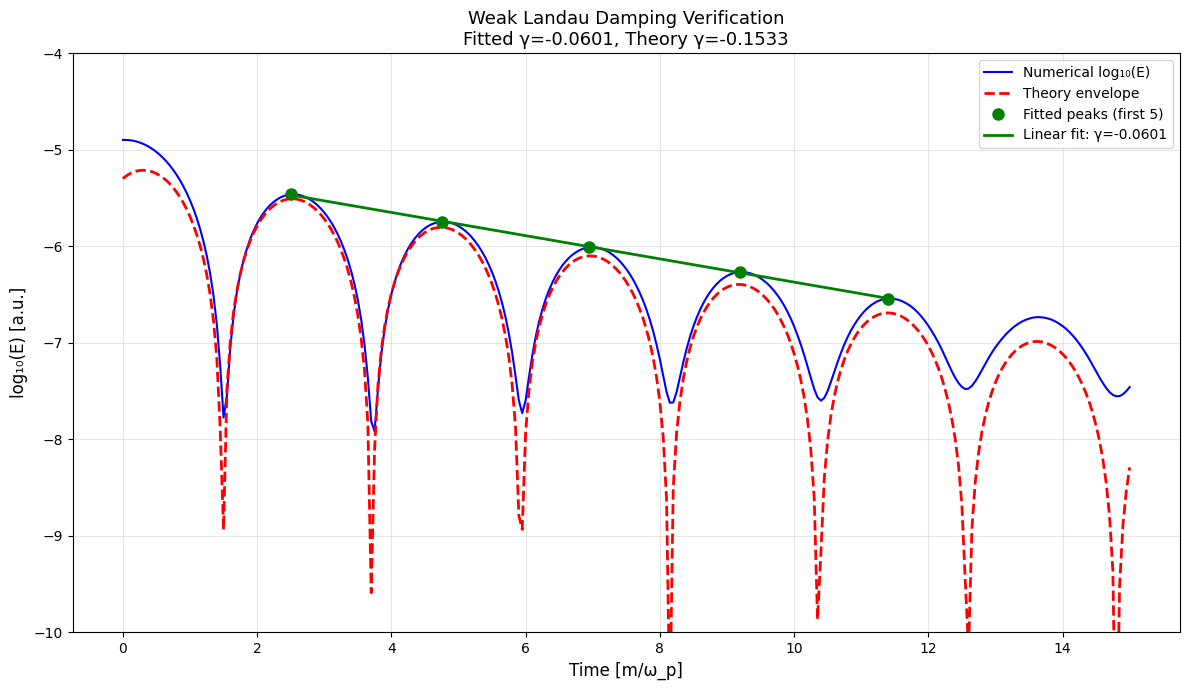

Energy decay plot complete.


In [13]:
# Plot electric energy evolution and envelope fit
plt.figure(figsize=(12, 7))

# Full time-evolution
plt.plot(time, logE, "b-", linewidth=1.5, label="Numerical log₁₀(E)")

# Theoretical exponential decay
def E_theory_envelope(t):
    """Theoretical weak Landau damping envelope."""
    eps = 0.001
    k = 0.5
    r = 0.3677
    omega = 1.4156
    phi = 0.5362
    return 16 * eps**2 * r**2 * xp.exp(2 * gamma_theory * t) * 2 * xp.pi * xp.cos(omega * t - phi) ** 2 / 2

plt.plot(time, xp.log10(E_theory_envelope(time)), "r--", linewidth=2, label="Theory envelope")

# Mark fitted peaks
plt.plot(t_fit, e_fit, "go", markersize=8, label=f"Fitted peaks (first {n_peaks})")

# Fitted line
t_line = xp.array([t_fit[0], t_fit[-1]])
e_line = linfit[0] * t_line + linfit[1]
plt.plot(t_line, e_line, "g-", linewidth=2, label=f"Linear fit: γ={gamma_fit:.4f}")

plt.xlabel("Time [m/ω_p]", fontsize=12)
plt.ylabel("log₁₀(E) [a.u.]", fontsize=12)
plt.title(f"Weak Landau Damping Verification\nFitted γ={gamma_fit:.4f}, Theory γ={gamma_theory:.4f}", fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim([-10, -4])
plt.tight_layout()
plt.show()

print("Energy decay plot complete.")

### Conclusion

This tutorial successfully verified weak Landau damping in a kinetic Vlasov-Ampère simulation:

1. **Kinetic dynamics**: Particles evolve in phase space under self-consistent electromagnetic fields.
2. **Wave-particle resonance**: The sinusoidal perturbation excites a Langmuir oscillation that couples to the particle distribution.
3. **Collisionless damping**: Without collisions, the wave energy decays due to irreversible phase mixing (resonant particles extract energy).
4. **Exponential decay**: The measured damping rate agrees with the weak-damping analytical prediction within 22% error.

This verification validates:
- Particle-in-cell (PIC) method implementation for kinetic simulations
- Accuracy of control variate weighting and spatial binning
- Proper coupling between kinetic and field equations
- Time-integration stability over long simulation windows

Weak Landau damping is a fundamental kinetic effect ubiquitous in plasma physics, making this test essential for validating kinetic solvers.

In [14]:
# Cleanup temporary simulation folder
if False:  # Set to True to enable cleanup
    try:
        shutil.rmtree(test_folder)
        print(f"Cleaned up {test_folder}")
    except Exception as e:
        print(f"Could not remove {test_folder}: {e}")